## Методичка

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import time
%matplotlib inline

In [47]:
n = 1024
time_signal = 1
t = np.linspace(0, time_signal, n, endpoint=True)
dn = np.random.random(len(t))
w = 2 + 17
ds = (20 * np.sin((2 * np.pi) * 2 * w * t) + 10 * np.sin((2 * np.pi) * 6 * w * t)) + dn

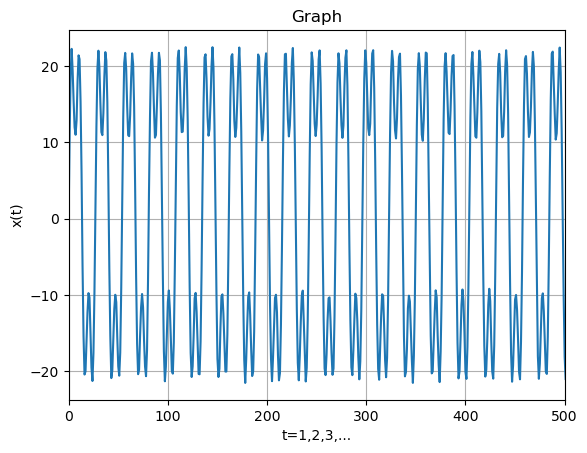

In [48]:
plt.plot(ds)
plt.xlabel('t=1,2,3,...')
plt.xlim(0,500)
plt.ylabel('x(t)')
plt.title('Graph')
plt.grid()
plt.show()

In [49]:
T = np.arange(n)
k = np.arange(n).reshape(n, 1)

In [50]:
Mm = np.exp(-2j * np.pi * k * T / n)
print(Mm.shape)

(1024, 1024)


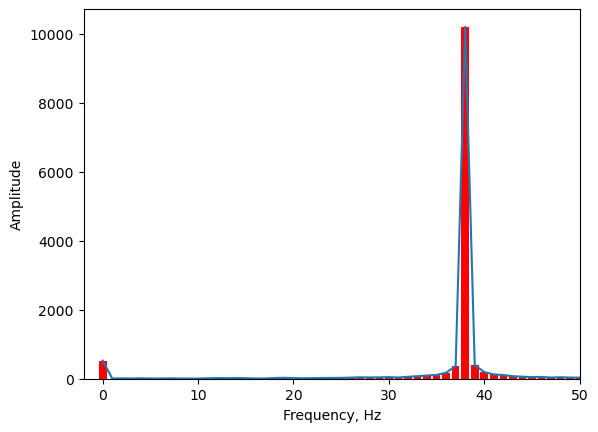

In [51]:
spectrum = np.dot(Mm, ds)

N = len(spectrum)
freq = np.arange(N) / time_signal

plt.figure()
plt.plot(freq, abs(spectrum))
plt.xlim(-2, 50)
plt.bar(freq, abs(spectrum), color='red')
plt.ylabel('Amplitude')
plt.xlabel('Frequency, Hz')
plt.show()

In [52]:
spectrum = np.dot(Mm, ds)

N = len(spectrum)
freq = np.arange(N)/time

plt.figure()
plt.plot(freq, abs(spectrum) / (1))
plt.xlim(-2,50)
plt.bar(freq, abs(spectrum) / (1), color = 'red')
plt.ylabel('Amplitude')
plt.xlabel('Frefrequency, H')
plt.show()

TypeError: unsupported operand type(s) for /: 'int' and 'module'

## Самостоятельно 

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

### Генерация сигнала

In [33]:
def generate_signal(N, f1=5, f2=15, A1=1, A2=0.5, sigma=0.1):
    t = np.linspace(0, 1, N, endpoint=False)
    noise = sigma * np.random.randn(N)
    signal = A1 * np.sin(2*np.pi*f1*t) + A2 * np.sin(2*np.pi*f2*t) + noise
    return t, signal

### Наивный алгоритм ДПФ O(N^2)

In [34]:
def naive_dft(x):
    N = len(x)
    X = np.zeros(N, dtype=complex)

    for k in range(N):
        for n in range(N):
            X[k] += x[n] * np.exp(-2j * np.pi * k * n / N)

    return X

### Замер времени

In [35]:
sizes = [100, 1000, 10000]
results = []

for N in sizes:
    _, signal = generate_signal(N)

    start = time.perf_counter()
    naive_dft(signal)
    end = time.perf_counter()

    execution_time = end - start

    results.append({"N": N, "Time (sec)": execution_time})

df = pd.DataFrame(results)
print(df)

       N  Time (sec)
0    100    0.010924
1   1000    0.984358
2  10000   99.002983


### График сложности

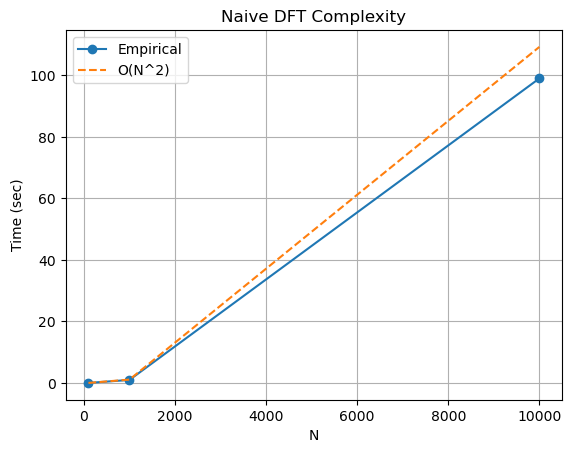

In [38]:
N_values = df["N"].values
T_values = df["Time (sec)"].values

plt.figure()
plt.plot(N_values, T_values, 'o-', label="Empirical")
plt.plot(N_values, T_values[0] * (N_values/N_values[0])**2,'--', label="O(N^2)")
plt.xlabel("N")
plt.ylabel("Time (sec)")
plt.title("Naive DFT Complexity")
plt.legend()
plt.grid()
plt.show()

### Метод наименьших квадратов T = C * N^2

In [39]:
N2 = N_values**2
C = np.sum(N2 * T_values) / np.sum(N2**2)

print(f"\nEstimated coefficient C = {C:.10e}")


Estimated coefficient C = 9.9002926389e-07
